Impelementation of Supervised Learning for Times Series in Python

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error



Membuat data time series contoh

In [9]:

dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
sales = np.random.randint(50, 200, size=len(dates))
df = pd.DataFrame({'Date': dates, 'Sales': sales})
df.set_index('Date', inplace=True)
df.head()       

,Sales
Date,
2023-01-01,139
2023-01-02,178
2023-01-03,116
2023-01-04,129
2023-01-05,104


In [10]:
df['Sales_lag1'] = df['Sales'].shift(1)
df['Sales_lag2'] = df['Sales'].shift(2)
df['Rolling_Mean_7'] = df['Sales'].rolling(window=7).mean()
df.dropna(inplace=True)

In [11]:
X = df[['Sales_lag1', 'Sales_lag2', 'Rolling_Mean_7']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Mean Squared Error: 866.3316315789475


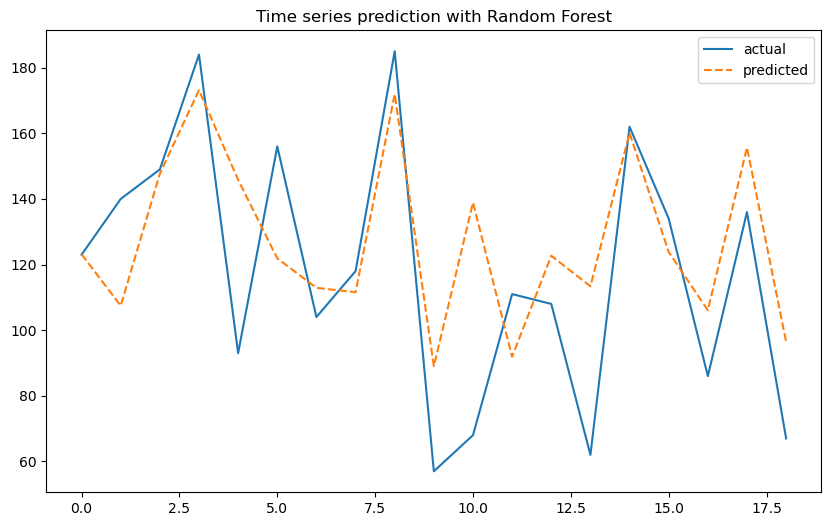

In [13]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label= "actual")
plt.plot(y_pred, label= "predicted", linestyle="dashed")
plt.legend()
plt.title('Time series prediction with Random Forest')
plt.show()